# CausalQTot Comparison: v2 EvtGen vs Neha event processing

1. Load v2 EvtGen files.
2. Load Neha's event-level HDF files from `neha_event/`.
3. List which events match and which are missing in each dataset.
4. For matching events, histogram the difference in CausalQTot.

In [26]:
import tables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load v2 EvtGen files

In [27]:
V2_BASE = "/data/user/tvaneede/GlobalFit/reco_processing/data/hese/output/v2"

DATASETS = [
    "IC79_2010",
    "IC86_2011",
    "IC86_2012",
    "IC86_2013",
    "IC86_2014",
    "IC86_2015",
    "IC86_2016",
    "IC86_2017",
    "IC86_2018",
    "IC86_2019",
    "IC86_2020",
    "IC86_2021",
    "IC86_2022",
]


def load_v2_evtgen():
    records = []
    for dataset in DATASETS:
        path = Path(V2_BASE) / dataset / "EvtGen" / "EvtGen.h5"
        if not path.exists():
            print(f"  {dataset}: MISSING")
            continue
        with tables.open_file(str(path), "r") as f:
            df_hdr = pd.DataFrame({
                "run":   f.root.I3EventHeader.col("Run"),
                "event": f.root.I3EventHeader.col("Event"),
            })
            df_en = pd.DataFrame({
                "run":         f.root.RecoETot.col("Run"),
                "event":       f.root.RecoETot.col("Event"),
                "reco_energy": f.root.RecoETot.col("value"),
            })
            df_qtot = pd.DataFrame({
                "run":              f.root.HESE_CausalQTot.col("Run"),
                "event":            f.root.HESE_CausalQTot.col("Event"),
                "hese_causal_qtot": f.root.HESE_CausalQTot.col("value"),
            })
        df = df_hdr.merge(df_en, on=["run", "event"], how="left")
        df = df.merge(df_qtot, on=["run", "event"], how="left")
        df.insert(0, "dataset", dataset)
        records.append(df)
        print(f"  {dataset}: {len(df)} events")
    result = pd.concat(records, ignore_index=True)
    print(f"  Total: {len(result)}")
    return result


print("=== v2 ===")
df_v2 = load_v2_evtgen()

=== v2 ===
  IC79_2010: 7 events
  IC86_2011: 21 events
  IC86_2012: 9 events
  IC86_2013: 16 events
  IC86_2014: 15 events
  IC86_2015: 9 events
  IC86_2016: 22 events
  IC86_2017: 18 events
  IC86_2018: 16 events
  IC86_2019: 19 events
  IC86_2020: 10 events
  IC86_2021: 12 events
  IC86_2022: 19 events
  Total: 193


## 2. Load Neha event-level HDF files

Files are at `neha_event/{dataset}.h5`, each containing a `CausalQTot` table.

In [28]:
NEHA_BASE = "/data/user/tvaneede/GlobalFit/reco_processing/data/hese/output/neha_event"


def load_neha_event():
    records = []
    for dataset in DATASETS:
        path = Path(NEHA_BASE) / f"{dataset}.h5"
        if not path.exists():
            print(f"  {dataset}: MISSING")
            continue
        with tables.open_file(str(path), "r") as f:
            df_hdr = pd.DataFrame({
                "run":   f.root.I3EventHeader.col("Run"),
                "event": f.root.I3EventHeader.col("Event"),
            })
            df_en = pd.DataFrame({
                "run":         f.root.RecoETot.col("Run"),
                "event":       f.root.RecoETot.col("Event"),
                "reco_energy": f.root.RecoETot.col("value"),
            })
            df_qtot = pd.DataFrame({
                "run":         f.root.CausalQTot.col("Run"),
                "event":       f.root.CausalQTot.col("Event"),
                "causal_qtot": f.root.CausalQTot.col("value"),
            })
        df = df_hdr.merge(df_en, on=["run", "event"], how="left")
        df = df.merge(df_qtot, on=["run", "event"], how="left")
        df.insert(0, "dataset", dataset)
        records.append(df)
        print(f"  {dataset}: {len(df)} events")
    result = pd.concat(records, ignore_index=True)
    print(f"  Total: {len(result)}")
    return result


print("=== Neha event processing ===")
df_neha = load_neha_event()

=== Neha event processing ===
  IC79_2010: 7 events
  IC86_2011: 19 events
  IC86_2012: 8 events
  IC86_2013: 15 events
  IC86_2014: 14 events
  IC86_2015: 8 events
  IC86_2016: 22 events
  IC86_2017: 18 events
  IC86_2018: 14 events
  IC86_2019: 18 events
  IC86_2020: 9 events
  IC86_2021: 12 events
  IC86_2022: MISSING
  Total: 164


## 3. Event-level comparison: v2 vs Neha

In [29]:
set_v2   = set(zip(df_v2["run"],   df_v2["event"]))
set_neha = set(zip(df_neha["run"], df_neha["event"]))

print(f"v2 events:             {len(set_v2)}")
print(f"Neha events:           {len(set_neha)}")
print(f"In both:               {len(set_v2 & set_neha)}")
print(f"Only in v2 (not Neha): {len(set_v2 - set_neha)}")
print(f"Only in Neha (not v2): {len(set_neha - set_v2)}")

v2 events:             193
Neha events:           164
In both:               163
Only in v2 (not Neha): 30
Only in Neha (not v2): 1


In [30]:
# Per-dataset summary
df_v2["in_neha"] = [
    k in set_neha for k in zip(df_v2["run"], df_v2["event"])
]
summary = df_v2.groupby("dataset")["in_neha"].agg(
    n_v2="count", n_in_neha="sum"
)
summary["n_only_v2"] = summary["n_v2"] - summary["n_in_neha"]
summary

,n_v2,n_in_neha,n_only_v2
dataset,,,
IC79_2010,7,7,0
IC86_2011,21,19,2
IC86_2012,9,8,1
IC86_2013,16,15,1
IC86_2014,15,13,2
IC86_2015,9,8,1
IC86_2016,22,22,0
IC86_2017,18,18,0
IC86_2018,16,14,2


### Events only in v2 — missing from Neha

In [31]:
only_v2 = df_v2[~df_v2["in_neha"]].reset_index(drop=True)
print(f"v2 events missing from Neha: {len(only_v2)}")
display(only_v2[["dataset", "run", "event", "reco_energy", "hese_causal_qtot"]])

v2 events missing from Neha: 30


,dataset,run,event,reco_energy,hese_causal_qtot
0,IC86_2011,119311,430943,3.269002e+05,14156.095864
1,IC86_2011,119583,141609,5.709847e+04,6875.744233
2,IC86_2012,121947,7181486,7.449678e+04,9355.539456
3,IC86_2013,123770,442256,4.169044e+06,6157.379055
4,IC86_2014,126359,9400616,2.526825e+04,6008.448549
5,IC86_2014,125826,470241,4.164990e+05,38785.083770
6,IC86_2015,127751,927145,2.326454e+05,8745.913758
7,IC86_2018,131680,66412090,2.252563e+05,15959.375007
8,IC86_2018,132143,36142391,1.993608e+05,6855.225000
9,IC86_2019,133685,952140,2.431965e+04,6073.425024


### Events only in Neha — missing from v2

In [32]:
df_neha["in_v2"] = [
    k in set_v2 for k in zip(df_neha["run"], df_neha["event"])
]
only_neha = df_neha[~df_neha["in_v2"]].reset_index(drop=True)
print(f"Neha events missing from v2: {len(only_neha)}")
display(only_neha[["dataset", "run", "event", "reco_energy", "causal_qtot"]])

Neha events missing from v2: 1


,dataset,run,event,reco_energy,causal_qtot
0,IC86_2014,125914,75630389,70976.904502,6000.117421


### Matching events

In [33]:
df_matching = df_v2[df_v2["in_neha"]].reset_index(drop=True)
print(f"Matching events: {len(df_matching)}")
display(df_matching[["dataset", "run", "event", "reco_energy", "hese_causal_qtot"]].head(10))

Matching events: 163


,dataset,run,event,reco_energy,hese_causal_qtot
0,IC79_2010,116528,52433389,68520.107392,8442.636503
1,IC79_2010,117371,31623515,30363.719017,8233.844019
2,IC79_2010,118145,5142726,58642.184623,6282.660629
3,IC79_2010,116698,10198436,148802.206659,11066.137793
4,IC79_2010,115994,2538090,44925.339101,6105.663898
5,IC79_2010,115994,29874216,102432.304963,12596.696886
6,IC79_2010,117782,49441871,23559.228620,6438.907011
7,IC86_2011,119474,33152537,28293.830981,6150.662853
8,IC86_2011,118283,9445773,82957.617448,7941.826037
9,IC86_2011,119214,8606380,65283.563149,7528.893319


## 4. Histogram of CausalQTot difference (matching events)

- **v2**: `HESE_CausalQTot`
- **Neha**: `CausalQTot`

Difference = Neha `CausalQTot` − v2 `HESE_CausalQTot`

In [34]:
df_comp = df_matching.merge(
    df_neha[["run", "event", "causal_qtot"]].rename(columns={"causal_qtot": "neha_causal_qtot"}),
    on=["run", "event"],
    how="inner",
)
df_comp["delta_qtot"] = df_comp["neha_causal_qtot"] - df_comp["hese_causal_qtot"]
df_comp["rel_delta_qtot"] = df_comp["delta_qtot"] / df_comp["hese_causal_qtot"]

print(f"Events compared: {len(df_comp)}")
print()
print("delta_qtot (Neha - v2):")
print(df_comp["delta_qtot"].describe())
print()
print("relative delta_qtot (Neha - v2) / v2:")
print(df_comp["rel_delta_qtot"].describe())

Events compared: 163

delta_qtot (Neha - v2):
count     163.000000
mean      -70.081611
std       362.027271
min     -4546.842111
25%       -62.374699
50%        -6.963777
75%         0.017992
max       249.064157
Name: delta_qtot, dtype: float64

relative delta_qtot (Neha - v2) / v2:
count    163.000000
mean      -0.003482
std        0.007414
min       -0.044227
25%       -0.006211
50%       -0.000835
75%        0.000003
max        0.027600
Name: rel_delta_qtot, dtype: float64


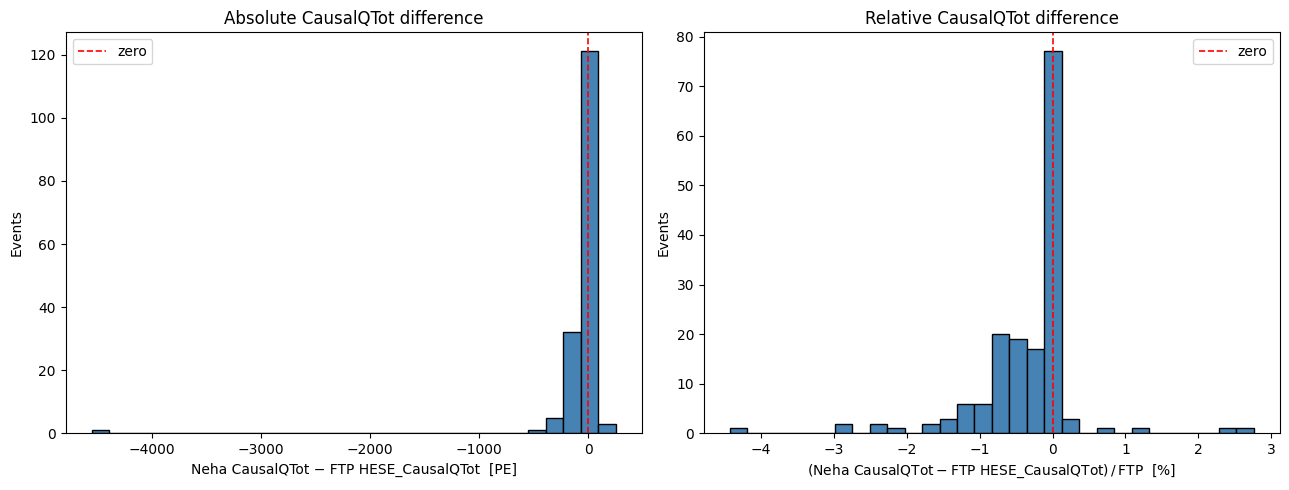

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute difference
ax = axes[0]
ax.hist(df_comp["delta_qtot"], bins=30, edgecolor="black", color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="zero")
ax.set_xlabel("Neha CausalQTot − FTP HESE_CausalQTot  [PE]")
ax.set_ylabel("Events")
ax.set_title("Absolute CausalQTot difference")
ax.legend()

# Relative difference
ax = axes[1]
ax.hist(df_comp["rel_delta_qtot"] * 100, bins=30, edgecolor="black", color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="zero")
ax.set_xlabel(r"$(\mathrm{Neha\ CausalQTot} - \mathrm{FTP\ HESE\_CausalQTot})\,/\,\mathrm{FTP}$  [%]")
ax.set_ylabel("Events")
ax.set_title("Relative CausalQTot difference")
ax.legend()

plt.tight_layout()
plt.show()

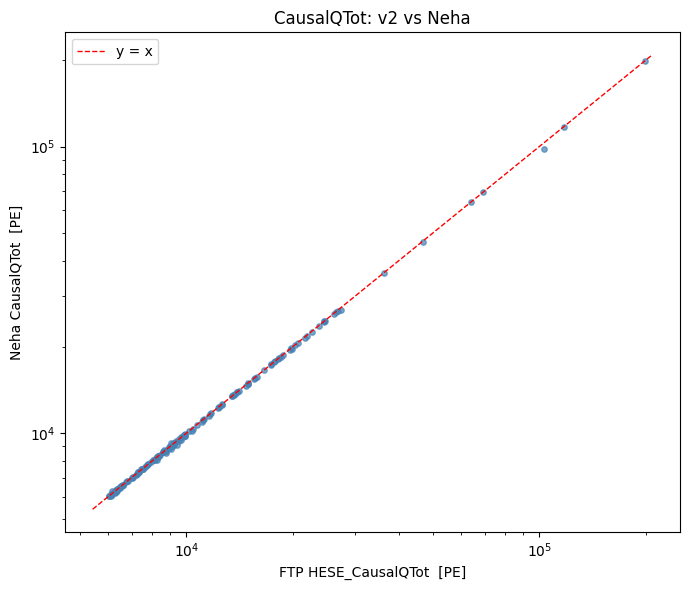

In [37]:
# Scatter: v2 CausalQTot vs Neha CausalQTot
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    df_comp["hese_causal_qtot"],
    df_comp["neha_causal_qtot"],
    s=15, alpha=0.7, color="steelblue",
)
lims = [
    min(df_comp["hese_causal_qtot"].min(), df_comp["neha_causal_qtot"].min()) * 0.9,
    max(df_comp["hese_causal_qtot"].max(), df_comp["neha_causal_qtot"].max()) * 1.05,
]
ax.plot(lims, lims, "r--", linewidth=1, label="y = x")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("FTP HESE_CausalQTot  [PE]")
ax.set_ylabel("Neha CausalQTot  [PE]")
ax.set_title("CausalQTot: v2 vs Neha")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Full table of matching events with both QTot values
display(
    df_comp[
        ["dataset", "run", "event", "reco_energy",
         "hese_causal_qtot", "neha_causal_qtot", "delta_qtot", "rel_delta_qtot"]
    ].sort_values("rel_delta_qtot", ascending=False).reset_index(drop=True)
)